# H&M Customer Preference and Product Popularity EDA

**Owner:** Binara  
**Module:** CCS4310 – Deep Learning  
**Project:** Explainable-Fashion-Design-AI

This notebook examines customer purchase behaviour, article attributes, product popularity, and time-based patterns using the local H&M Personalized Fashion Recommendations data. It does not train a model. Customer identifiers remain anonymous and all findings are based on executed local data.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')

def find_repo_root():
    here = Path.cwd().resolve()
    candidates = [here, *here.parents]
    for p in candidates:
        if (p / 'data' / 'raw' / 'hm').is_dir() and (p / 'requirements.txt').exists():
            return p
    raise FileNotFoundError('Repository root with data/raw/hm and requirements.txt was not found.')

ROOT = find_repo_root()
HM_DIR = ROOT / 'data' / 'raw' / 'hm'
ARTICLES_PATH = HM_DIR / 'articles.csv'
CUSTOMERS_PATH = HM_DIR / 'customers.csv'
TRANSACTIONS_PATH = HM_DIR / 'transactions_train.csv'
OUTPUT_FIGURES_DIR = ROOT / 'outputs' / 'figures'
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('Using the existing shared repository .venv / selected project kernel.')
print('Python:', sys.executable)
print('Repository:', ROOT)

Using the existing shared repository .venv / selected project kernel.
Python: d:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\.venv\Scripts\python.exe
Repository: D:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI


In [2]:
inventory = []
for path in sorted(HM_DIR.iterdir()):
    inventory.append({'file': path.name, 'type': 'directory' if path.is_dir() else path.suffix.lstrip('.').upper() or 'file', 'approx_size_mb': round(path.stat().st_size / 1024**2, 3) if path.is_file() else np.nan, 'exists': path.exists()})
inventory_df = pd.DataFrame(inventory)
display(inventory_df)

,file,type,approx_size_mb,exists
0,articles.csv,CSV,34.454,True
1,customers.csv,CSV,197.540,True
2,images,directory,NaN,True
3,README.md,MD,0.000,True
4,sample_submission.csv,CSV,257.759,True
5,transactions_train.csv,CSV,3326.418,True


In [3]:
def normalize_article_id(series):
    return series.astype('string').str.strip().str.zfill(10)

articles = pd.read_csv(ARTICLES_PATH, dtype={'article_id':'string'})
articles['article_id'] = normalize_article_id(articles['article_id'])
customers = pd.read_csv(CUSTOMERS_PATH, dtype={'customer_id':'string', 'postal_code':'string'})
print('ARTICLES shape:', articles.shape)
display(pd.DataFrame({'dtype': articles.dtypes.astype(str), 'missing': articles.isna().sum(), 'nunique': articles.nunique(dropna=True)}))
print('Article duplicates:', int(articles.duplicated().sum()))
display(articles.head(3))
print('CUSTOMERS shape:', customers.shape)
display(pd.DataFrame({'dtype': customers.dtypes.astype(str), 'missing': customers.isna().sum(), 'nunique': customers.nunique(dropna=True)}))
print('Customer duplicates:', int(customers.duplicated().sum()))
display(customers.drop(columns=['customer_id','postal_code'], errors='ignore').head(3))
print('Customer identifiers are used only as anonymous grouping/join keys; no identity inference is performed.')

ARTICLES shape: (105542, 25)


,dtype,missing,nunique
article_id,string,0,105542
product_code,int64,0,47224
prod_name,str,0,45875
product_type_no,int64,0,132
product_type_name,str,0,131
product_group_name,str,0,19
graphical_appearance_no,int64,0,30
graphical_appearance_name,str,0,30
colour_group_code,int64,0,50
colour_group_name,str,0,50


Article duplicates: 0


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,0108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,0108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,0108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.


CUSTOMERS shape: (1371980, 7)


,dtype,missing,nunique
customer_id,string,0,1371980
FN,float64,895050,1
Active,float64,907576,1
club_member_status,str,6062,3
fashion_news_frequency,str,16011,3
age,float64,15861,84
postal_code,string,0,352899


Customer duplicates: 0


,FN,Active,club_member_status,fashion_news_frequency,age
0,NaN,NaN,ACTIVE,NONE,49.0
1,NaN,NaN,ACTIVE,NONE,25.0
2,NaN,NaN,ACTIVE,NONE,24.0


Customer identifiers are used only as anonymous grouping/join keys; no identity inference is performed.


In [4]:
TX_COLS = ['t_dat','customer_id','article_id','price','sales_channel_id']
TX_CHUNK = 250_000
FAST_DEV_RUN = True
MAX_TRANSACTIONS_DEV = 750_000
tx_parts = []
row_count = 0
for chunk in pd.read_csv(TRANSACTIONS_PATH, usecols=TX_COLS, dtype={'customer_id':'string','article_id':'string','price':'float32','sales_channel_id':'int8'}, chunksize=TX_CHUNK):
    chunk['article_id'] = normalize_article_id(chunk['article_id'])
    tx_parts.append(chunk)
    row_count += len(chunk)
    if FAST_DEV_RUN and row_count >= MAX_TRANSACTIONS_DEV:
        break
transactions = pd.concat(tx_parts, ignore_index=True).head(MAX_TRANSACTIONS_DEV if FAST_DEV_RUN else None)
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'], errors='coerce')
print(f'Loaded {row_count:,} transaction rows in chunks; development frame shape: {transactions.shape}')
print('Date range:', transactions['t_dat'].min(), 'to', transactions['t_dat'].max())
print('Unique customers:', transactions['customer_id'].nunique(), '| unique articles:', transactions['article_id'].nunique())
display(transactions.head(3))
print('Quality counts:', {'invalid_dates': int(transactions['t_dat'].isna().sum()), 'missing_customer_id': int(transactions['customer_id'].isna().sum()), 'missing_article_id': int(transactions['article_id'].isna().sum()), 'invalid_price': int((transactions['price'] < 0).sum()), 'duplicate_rows': int(transactions.duplicated().sum())})

Loaded 750,000 transaction rows in chunks; development frame shape: (750000, 5)
Date range: 2018-09-20 00:00:00 to 2018-10-05 00:00:00
Unique customers: 171406 | unique articles: 27137


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,0505221004,0.015237,2


Quality counts: {'invalid_dates': 0, 'missing_customer_id': 0, 'missing_article_id': 0, 'invalid_price': 0, 'duplicate_rows': 65446}


Article metadata match report: analysed=684,554; matched=684,554; unmatched=0; match_rate=100.00%


,purchases
product_type_name,
Sweater,132607
Trousers,111719
T-shirt,43616
Dress,36645
Blouse,33614
Top,26730
Bra,21827
Shirt,21046
Leggings/Tights,20608


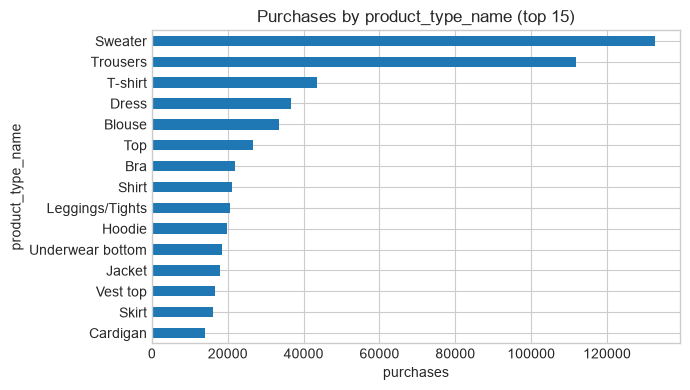

,purchases
product_group_name,
Garment Upper body,346751
Garment Lower body,154407
Underwear,43319
Garment Full body,41586
Accessories,38089
Socks & Tights,20942
Shoes,17039
Swimwear,14020
Nightwear,7728


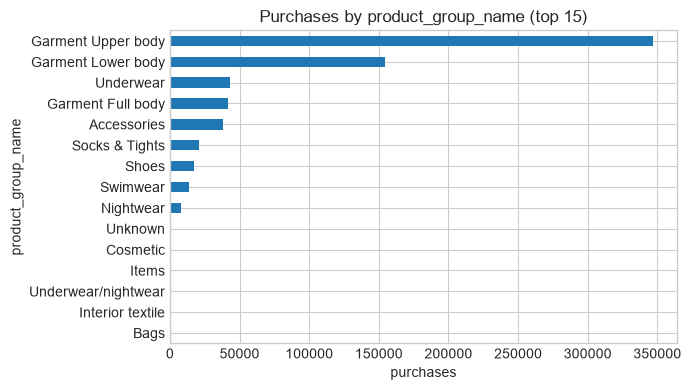

,purchases
garment_group_name,
Jersey Fancy,113137
Knitwear,99762
Jersey Basic,72207
Trousers,66665
"Under-, Nightwear",51170
Blouses,45873
Accessories,38835
Trousers Denim,35181
Dresses Ladies,25005


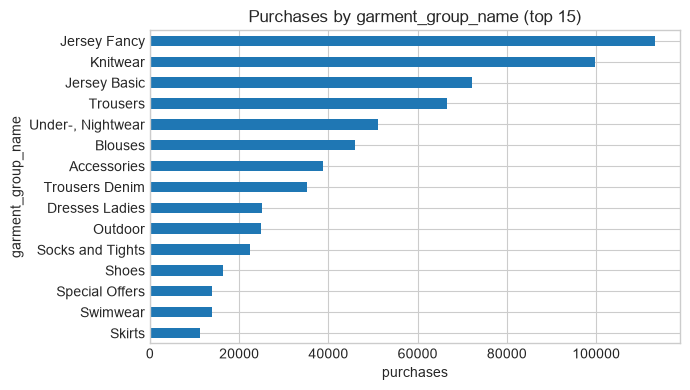

,purchases
department_name,
Knitwear,58700
Trouser,39479
Blouse,31591
Jersey Basic,29167
Tops Knitwear,23732
Jersey,23689
Basic 1,22976
Expressive Lingerie,20991
Tops Fancy Jersey,17943


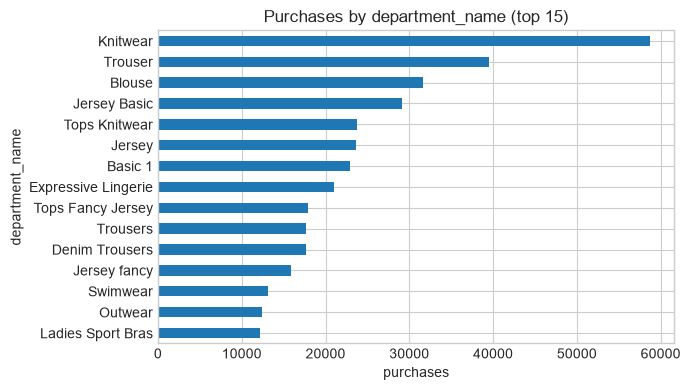

,purchases
section_name,
Womens Everyday Collection,122259
Divided Collection,86449
Womens Tailoring,44974
Womens Everyday Basics,36536
Womens Lingerie,33822
Divided Basics,26075
"Womens Nightwear, Socks & Tigh",24572
Ladies Denim,23320
Ladies H&M Sport,21813


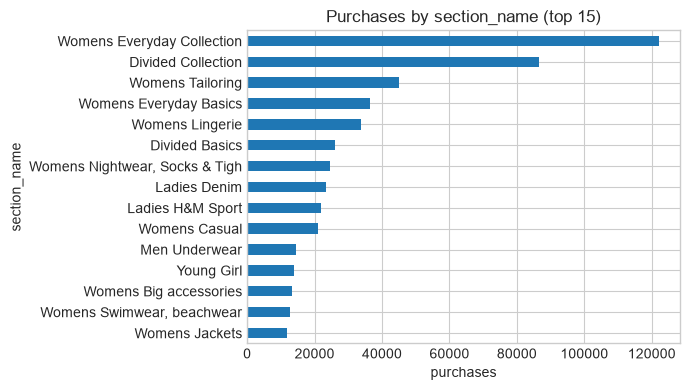

,purchases
colour_group_name,
Black,239392
Dark Blue,67212
White,54034
Grey,32992
Dark Red,26733
Dark Grey,26288
Blue,24001
Light Pink,21159
Light Blue,18287


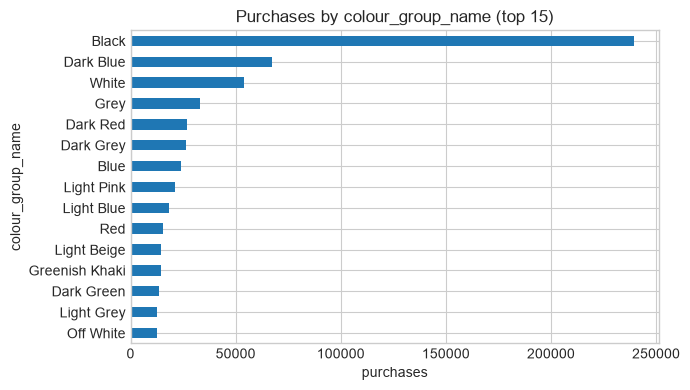

In [5]:
# Join article metadata after both sides have been normalized to the confirmed 10-character H&M format.
article_key = articles.copy()
tx = transactions.dropna(subset=['t_dat','customer_id','article_id']).query('price >= 0').drop_duplicates().copy()
tx_articles = tx.merge(article_key, on='article_id', how='left', validate='many_to_one', indicator=True)
matched = int((tx_articles['_merge'] == 'both').sum())
unmatched = int((tx_articles['_merge'] == 'left_only').sum())
print(f'Article metadata match report: analysed={len(tx_articles):,}; matched={matched:,}; unmatched={unmatched:,}; match_rate={matched / max(1, len(tx_articles)):.2%}')
if unmatched:
    print('Examples of unmatched normalized article IDs:', tx_articles.loc[tx_articles['_merge'] == 'left_only', 'article_id'].drop_duplicates().head(10).tolist())
tx_articles = tx_articles.drop(columns='_merge')
category_cols = ['product_type_name','product_group_name','garment_group_name','department_name','section_name','colour_group_name']
for col in category_cols:
    if col in tx_articles:
        counts = tx_articles[col].value_counts(dropna=False).head(15)
        display(counts.rename('purchases').to_frame().style.set_caption(col))
        ax = counts.sort_values().plot.barh(figsize=(7,4), title=f'Purchases by {col} (top 15)')
        ax.set_xlabel('purchases'); plt.tight_layout(); plt.savefig(OUTPUT_FIGURES_DIR / f'binara_hm_{col}_popularity.png', dpi=120); plt.show(); plt.close()

Customer behaviour


,purchase_count
count,171406.000000
mean,3.993758
std,4.000193
min,1.000000
50%,3.000000
75%,5.000000
90%,8.000000
99%,20.000000
max,163.000000


Repeat-customer share: 0.7449
Customers with one purchase: 43719


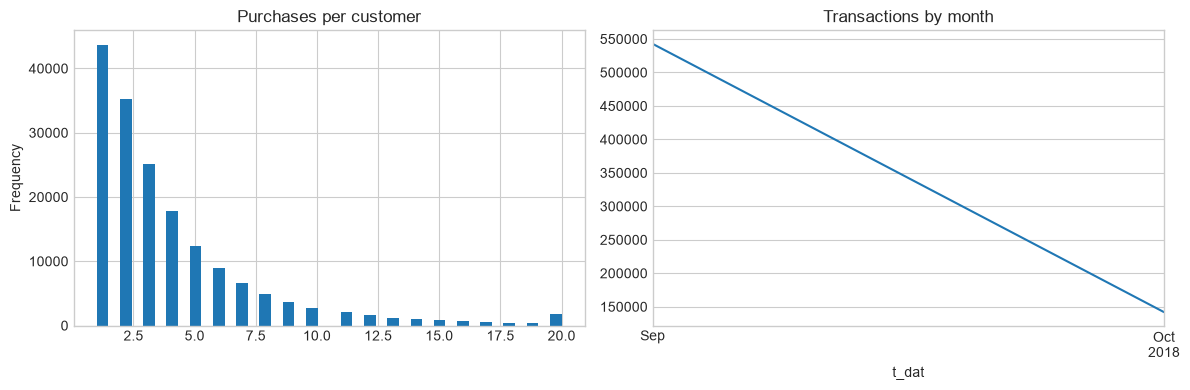

Most purchased articles


,purchase_count
article_id,
0539723005,1567
0399223001,1228
0685687003,1211
0685687004,1192
0685687001,1138
0685687002,1117
0692454002,1048
0573716012,1005
0637673005,939


,purchases
product_group_name,
Garment Upper body,346751
Garment Lower body,154407
Underwear,43319
Garment Full body,41586
Accessories,38089
Socks & Tights,20942
Shoes,17039
Swimwear,14020
Nightwear,7728


In [6]:
customer_counts = tx.groupby('customer_id').size().rename('purchase_count')
article_counts = tx.groupby('article_id').size().rename('purchase_count')
print('Customer behaviour')
display(customer_counts.describe(percentiles=[.5,.75,.9,.99]).to_frame())
print('Repeat-customer share:', round(float((customer_counts > 1).mean()), 4))
print('Customers with one purchase:', int((customer_counts == 1).sum()))
fig, axes = plt.subplots(1,2, figsize=(12,4))
customer_counts.clip(upper=customer_counts.quantile(.99)).plot.hist(bins=40, ax=axes[0], title='Purchases per customer')
tx.groupby('t_dat').size().resample('MS').sum().plot(ax=axes[1], title='Transactions by month')
plt.tight_layout(); plt.savefig(OUTPUT_FIGURES_DIR / 'binara_hm_customer_time_behaviour.png', dpi=120); plt.show(); plt.close()
print('Most purchased articles')
display(article_counts.sort_values(ascending=False).head(15).to_frame())
display(tx_articles.groupby('product_group_name').size().sort_values(ascending=False).head(15).rename('purchases').to_frame())

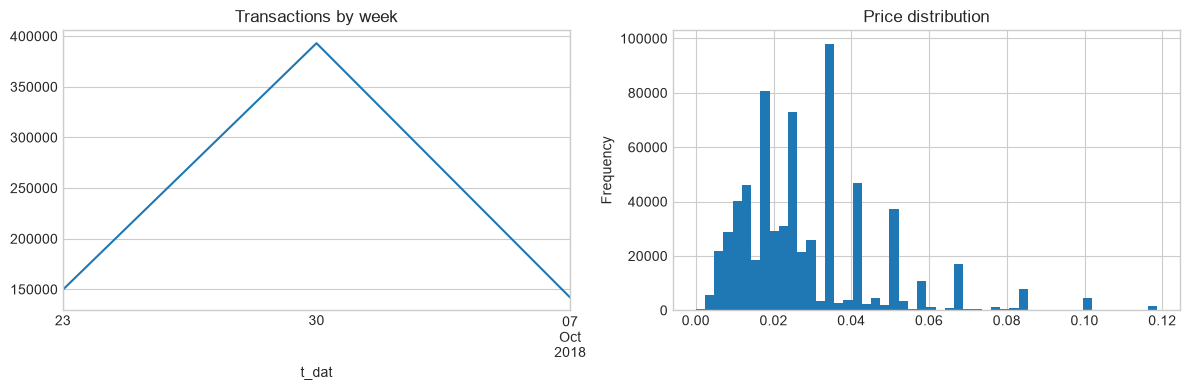

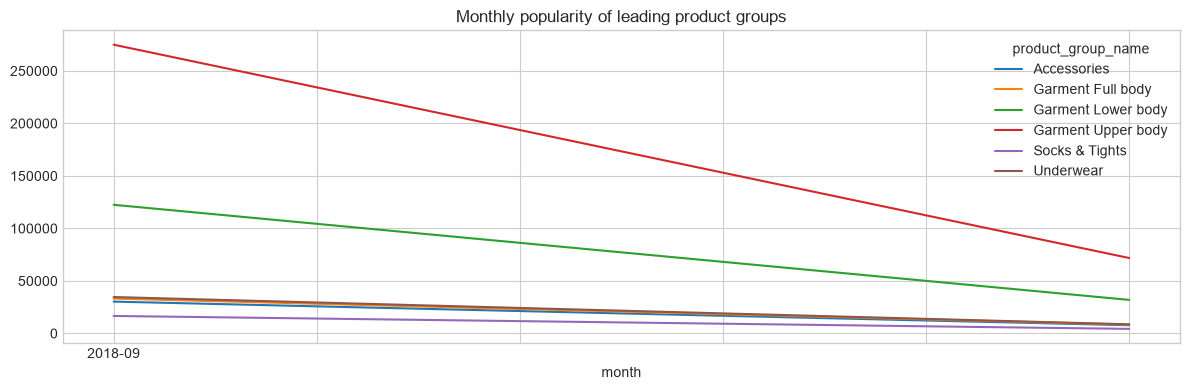

In [7]:
weekly = tx.set_index('t_dat').resample('W').size()
fig, axes = plt.subplots(1,2, figsize=(12,4))
weekly.plot(ax=axes[0], title='Transactions by week')
tx['price'].plot.hist(bins=50, ax=axes[1], title='Price distribution', range=(0, float(tx['price'].quantile(.99))))
plt.tight_layout(); plt.savefig(OUTPUT_FIGURES_DIR / 'binara_hm_transaction_distributions.png', dpi=120); plt.show(); plt.close()
if 'product_group_name' in tx_articles:
    monthly_group = tx_articles.assign(month=tx_articles['t_dat'].dt.to_period('M').astype(str)).groupby(['month','product_group_name']).size().reset_index(name='purchases')
    top_groups = monthly_group.groupby('product_group_name')['purchases'].sum().nlargest(6).index
    monthly_group = (
        tx_articles
        .dropna(subset=['t_dat', 'product_group_name'])
        .assign(month=lambda d: d['t_dat'].dt.to_period('M').astype(str))
        .groupby(['month', 'product_group_name'], dropna=True)
        .size()
        .reset_index(name='purchases')
    )

    if not monthly_group.empty:
        top_groups = (
            monthly_group.groupby('product_group_name', dropna=True)['purchases']
            .sum()
            .nlargest(6)
            .index
        )

        plot_df = (
            monthly_group[monthly_group['product_group_name'].isin(top_groups)]
            .pivot(index='month', columns='product_group_name', values='purchases')
            .sort_index()
        )

        if not plot_df.empty and not plot_df.select_dtypes(include=['number']).empty:
            plot_df.plot(figsize=(12, 4), title='Monthly popularity of leading product groups')
    plt.tight_layout(); plt.savefig(OUTPUT_FIGURES_DIR / 'binara_hm_monthly_product_popularity.png', dpi=120); plt.show(); plt.close()

## Leakage review and preference problem definition

Popularity is a useful baseline signal, not automatically a customer's preference. For a prediction time *t*, customer history, article popularity, prices, and labels must be computed only from records strictly before *t*. Future purchases, future activity, future popularity, and future prices would leak the answer.

**Target task:** Given a customer's historical interactions and product information available before a prediction time, rank fashion articles that the customer is more likely to purchase or prefer. This notebook reports executed EDA findings only; it does not claim model performance.

In [8]:
print('Executed EDA conclusion')
print(f'Articles: {len(articles):,}; customers: {len(customers):,}; analysed transactions: {len(tx):,}.')
print(f'Transactions span {tx.t_dat.min().date()} to {tx.t_dat.max().date()} after basic validation.')
print(f'Median purchases per customer: {customer_counts.median():.1f}; repeat-customer share: {(customer_counts > 1).mean():.2%}.')
print('Popularity summaries and plots above are descriptive signals. No model was trained and no unsupported preference claim is made.')

Executed EDA conclusion
Articles: 105,542; customers: 1,371,980; analysed transactions: 684,554.
Transactions span 2018-09-20 to 2018-10-05 after basic validation.
Median purchases per customer: 3.0; repeat-customer share: 74.49%.
Popularity summaries and plots above are descriptive signals. No model was trained and no unsupported preference claim is made.
